# Assignment: Decision Trees and Random Forests

## 1. Business Understanding

**Objective:**  
Build a model to classify websites as phishing or legitimate using easily obtainable features.

**Goals:**  
1. Use a **Decision Tree** for a transparent, human-readable model.  
2. Use a **Random Forest** to improve predictive performance.  
3. Provide **manual rules for analysts** derived from the Decision Tree.

**Motivation:**  
- Phishing websites steal sensitive data.  
- Early detection can prevent fraud and protect users.  
- Decision Trees allow interpretable rules; Random Forests improve accuracy.


## 2. Data Understanding

The dataset contains about 11,000 websites, each described by 30 features. The target variable `result` indicates whether a website is legitimate (1) or phishing (-1). Most features are categorical and take values -1 (bad), 0 (suspicious), or 1 (good). 

We first load the data and display the first few rows to see its structure. We also count how many websites belong to each class to understand the distribution of legitimate and phishing sites.

In [30]:
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import pandas as pd

# Fetch dataset
phishing_websites = fetch_ucirepo(id=327)
data = phishing_websites.data.original

# Quick overview
print(data.head())

# Count phishing vs legitimate websites
legitimate_count = data[data['result'] == 1].shape[0]
phishing_count = data[data['result'] == -1].shape[0]
print(f'Legitimate websites: {legitimate_count}')
print(f'Phishing websites: {phishing_count}')

   having_ip_address  url_length  shortining_service  having_at_symbol  \
0                 -1           1                   1                 1   
1                  1           1                   1                 1   
2                  1           0                   1                 1   
3                  1           0                   1                 1   
4                  1           0                  -1                 1   

   double_slash_redirecting  prefix_suffix  having_sub_domain  sslfinal_state  \
0                        -1             -1                 -1              -1   
1                         1             -1                  0               1   
2                         1             -1                 -1              -1   
3                         1             -1                 -1              -1   
4                         1             -1                  1               1   

   domain_registration_length  favicon  ...  popupwindow  iframe  \


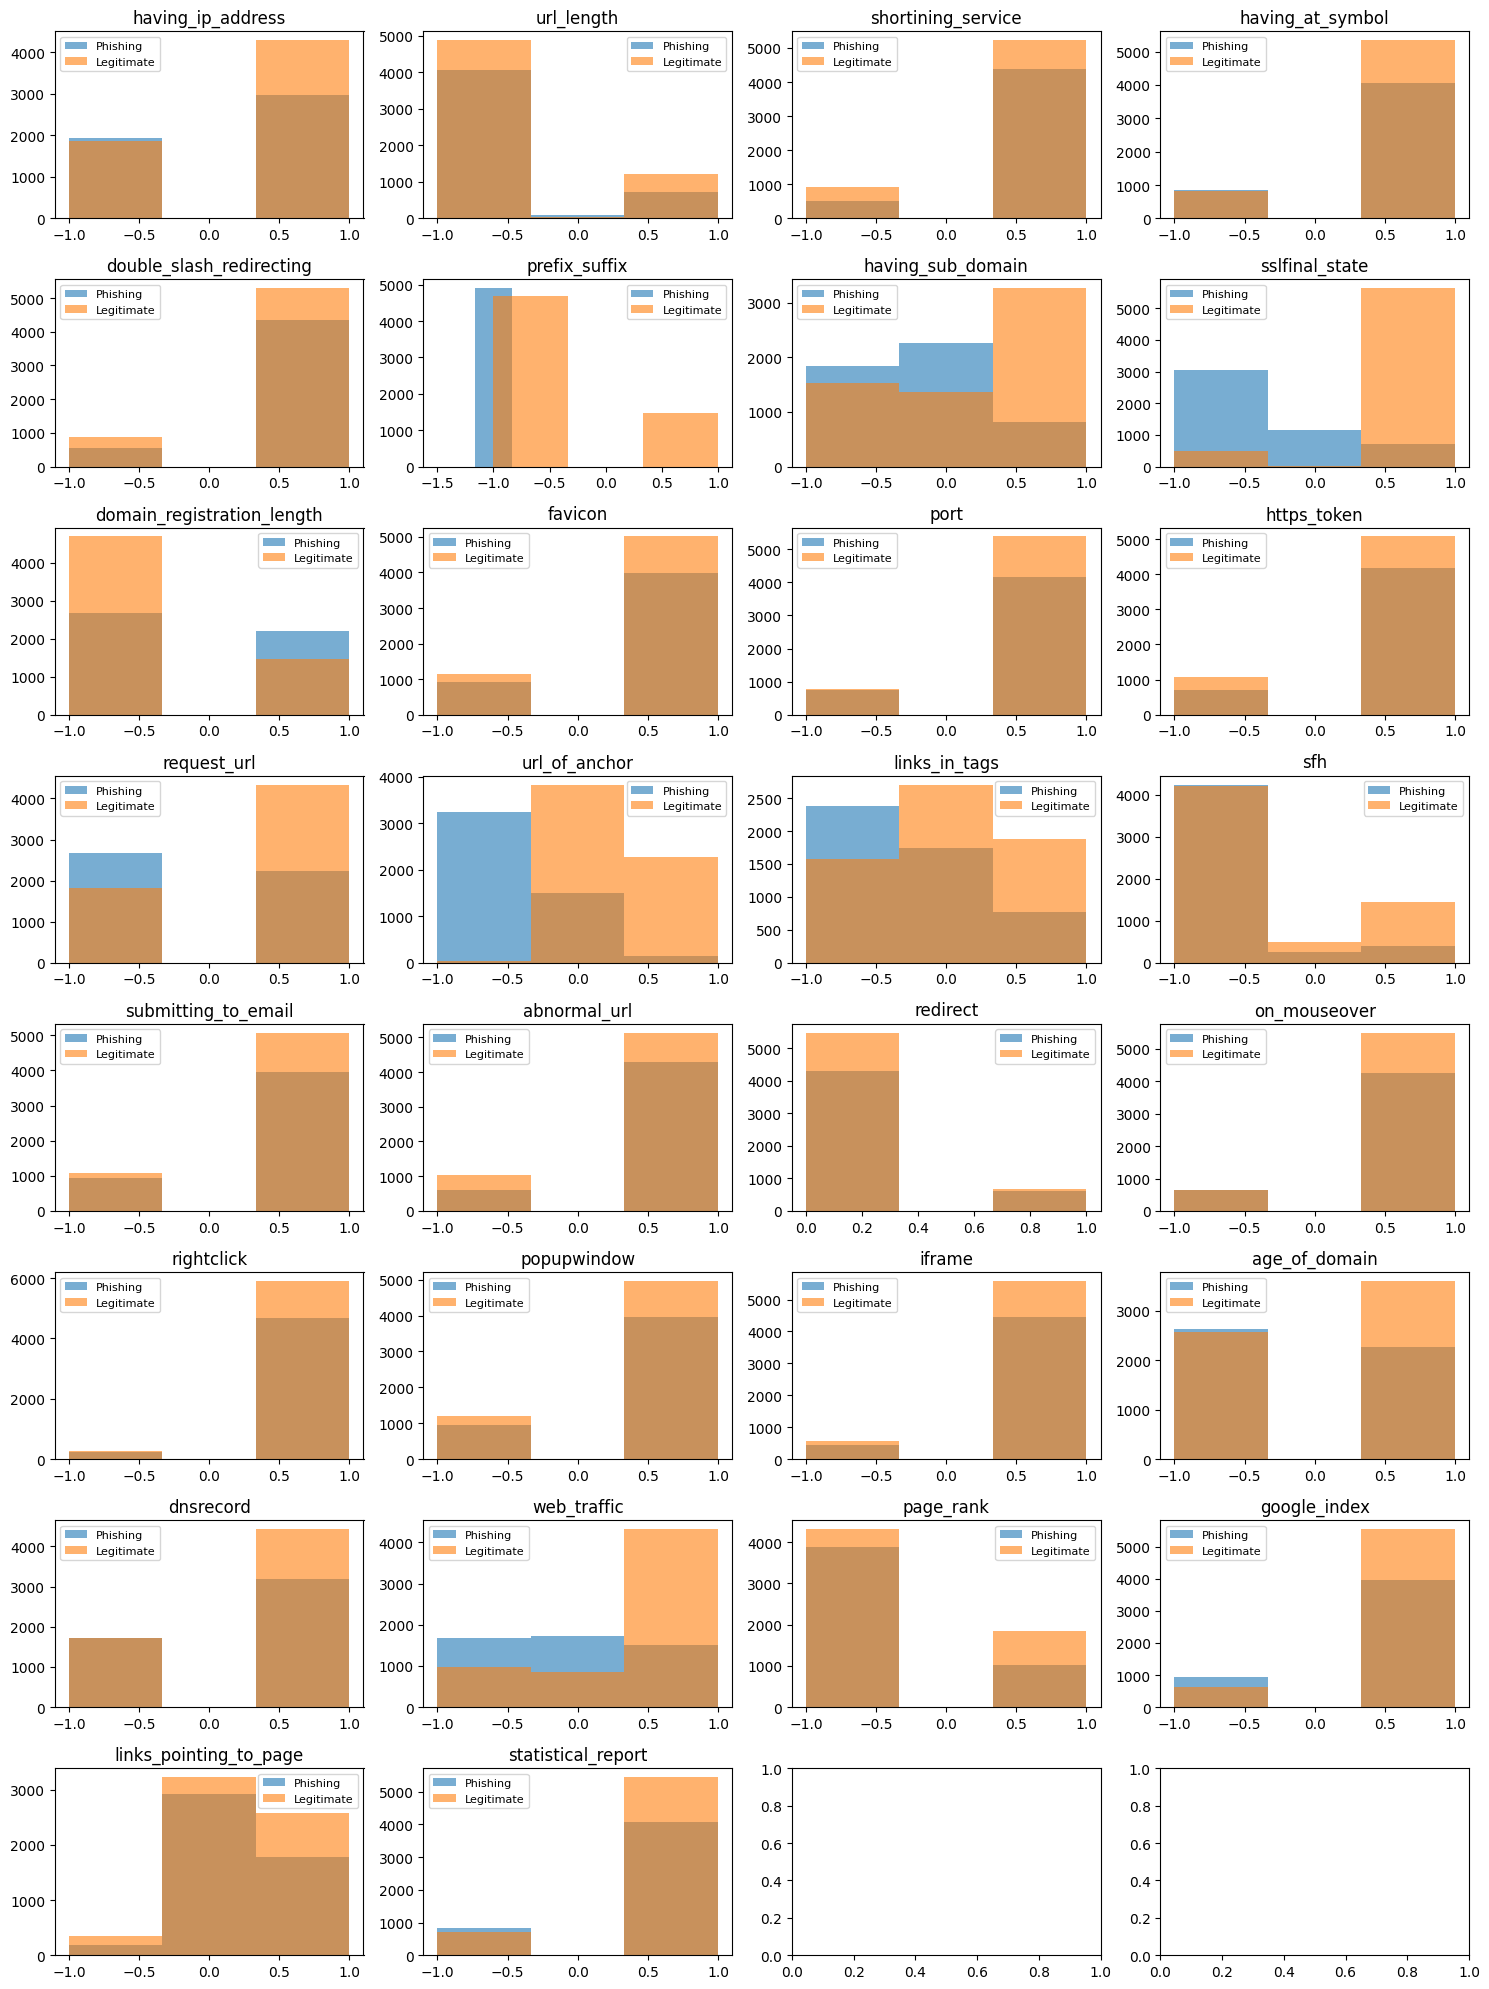

In [36]:
# Split into classes
phishing_data = data[data['result'] == -1].drop(columns=['result'])
legitimate_data = data[data['result'] == 1].drop(columns=['result'])

# Plot histograms
fig, axes = plt.subplots(8, 4, figsize=(15, 20))
axes = axes.flatten()

for i, column in enumerate(phishing_data.columns):
    ax = axes[i]
    ax.hist(phishing_data[column], alpha=0.6, label='Phishing', bins=3)
    ax.hist(legitimate_data[column], alpha=0.6, label='Legitimate', bins=3)
    ax.set_title(column)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Data Preparation

The dataset is split into features (`X`) and the target variable (`y`). The data is then divided into a training set and a test set, with 80% of the data used for training and 20% for testing. This split allows the models to learn patterns from the training set and be evaluated on unseen data in the test set. The number of legitimate and phishing websites in each set is displayed to show the class distribution.

In [37]:
from sklearn.model_selection import train_test_split

# Features and target
X = data.drop(columns=['result'])
y = data['result']

# Train-test split
random_state = 20
test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state
)

# Class distribution
print("Training set (Legitimate):", (y_train == 1).sum(), ", Phishing:", (y_train == -1).sum())
print("Test set (Legitimate):", (y_test == 1).sum(), ", Phishing:", (y_test == -1).sum())

Training set - Legitimate: 4918 , Phishing: 3926
Test set - Legitimate: 1239 , Phishing: 972


## 4. Modeling: Decision Tree and Random Forest

### 4.1 Modeling: Decision Tree

In this section, a decision tree classifier is created using the training data. The tree is limited to a maximum depth of 3 to keep it small and easy to interpret. Each leaf node contains at least a few samples to avoid overfitting. The decision tree automatically selects features and thresholds that best separate phishing and legitimate websites based on the training data.

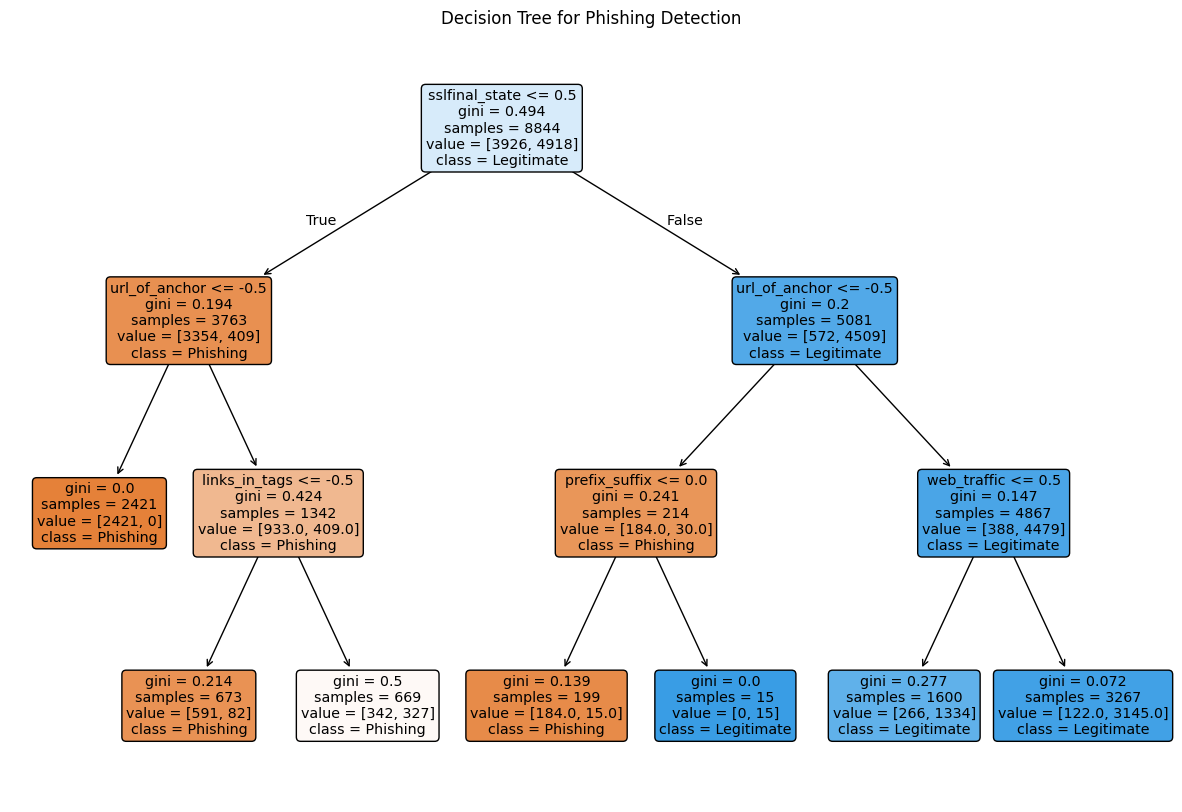

In [44]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train Decision Tree
max_depth = 3 
DecisionTreeModel = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)
DecisionTreeModel.fit(X_train, y_train)

# Visualize tree
plt.figure(figsize=(15,10))
plot_tree(
    DecisionTreeModel, 
    feature_names=X.columns, 
    class_names=['Phishing', 'Legitimate'],
    rounded=True, filled=True
)
plt.title("Decision Tree for Phishing Detection")
plt.show()

### 4.2 Modeling Random Forest

A random forest classifier is created using the training data. The model consists of 100 individual decision trees, each limited to a maximum depth of 5. Each tree is trained on a random subset of the data and a random subset of the features. This approach helps reduce overfitting and improves generalization compared to a single decision tree. The model also calculates an score as an internal estimate of prediction accuracy.

In [40]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
RandomForestModel = RandomForestClassifier(
    max_depth=5,
    n_estimators=100,
    bootstrap=True,
    max_samples=0.7,
    max_features=0.75,
    random_state=random_state,
    oob_score=True
)
RandomForestModel.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, max_features=0.75, max_samples=0.7,
                       oob_score=True, random_state=20)

## 5. Evaluation - Decision Tree and Random Forest

### 5.1 Evaluation (Decision Tree)

The trained decision tree is used to make predictions on the test data. Its performance is measured using metrics such as accuracy, precision, recall, and F1-score, which give an overall sense of how well the model can distinguish phishing and legitimate websites. A confusion matrix is also displayed to show the number of correct and incorrect predictions for each class.

Decision Tree Performance:
              precision    recall  f1-score   support

    Phishing       0.88      0.91      0.90       972
  Legitimate       0.93      0.90      0.92      1239

    accuracy                           0.91      2211
   macro avg       0.90      0.91      0.91      2211
weighted avg       0.91      0.91      0.91      2211



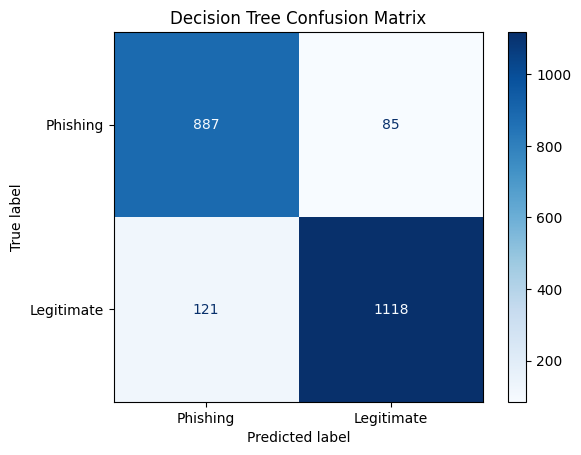

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred_dt = DecisionTreeModel.predict(X_test)

# Classification report
print("Decision Tree Performance:")
print(classification_report(y_test, y_pred_dt, target_names=['Phishing', 'Legitimate']))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Phishing', 'Legitimate'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Decision Tree Confusion Matrix")
plt.show()


### Decision Tree Visualization

The decision tree is visualized to show how it classifies websites. The tree splits the data based on the most informative features, with the root node often checking the SSL certificate status. Subsequent splits use features such as URL length, the presence of hyphens in the domain, and web traffic. Each leaf node shows the predicted class for that combination of feature values.

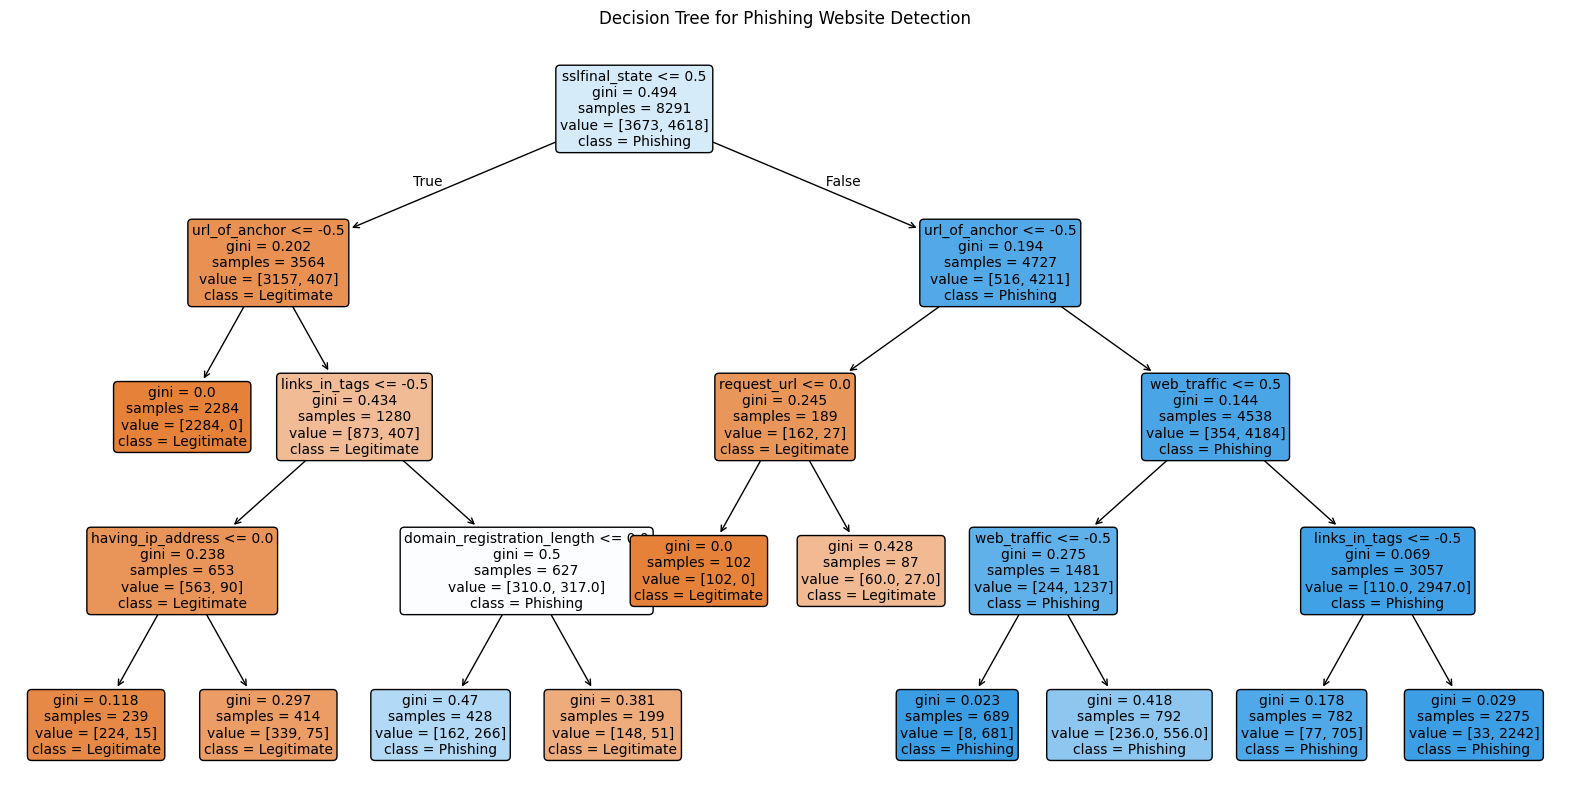

In [23]:
plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Legitimate","Phishing"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for Phishing Website Detection")
plt.show()

### 5.2 Evaluation (Random Forest)

Random Forest Performance:
              precision    recall  f1-score   support

    Phishing       0.94      0.91      0.92       972
  Legitimate       0.93      0.95      0.94      1239

    accuracy                           0.93      2211
   macro avg       0.94      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211



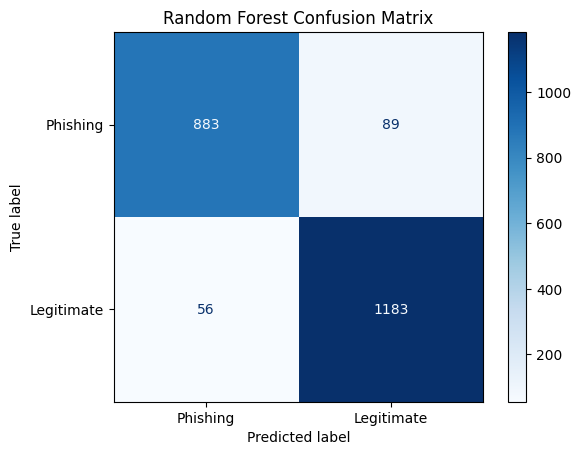

In [43]:
# Predictions
y_pred_rf = RandomForestModel.predict(X_test)

# Classification report
print("Random Forest Performance:")
print(classification_report(y_test, y_pred_rf, target_names=['Phishing', 'Legitimate']))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Phishing', 'Legitimate'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.show()

## 6. Deployment / Conclusion

The decision tree model is easy to interpret and can be used to guide human analysts when evaluating websites. Analysts can follow the tree’s rules to quickly identify suspicious or phishing websites.

The random forest model is more accurate and robust because it combines multiple trees. It can be used for automated, real-time detection of phishing websites.

In practice, the random forest model could be integrated into a website-checking service. The decision tree can be used alongside it to explain why a website is flagged as suspicious, showing which features contributed to the classification. Even if a site is classified as legitimate, analysts can be alerted if there are multiple suspicious attributes.